## Revising supervised ml : 23/4/26

In [57]:
### importing the important libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.stats as stat
import pylab

In [23]:
### loading the data frame
df = pd.read_csv('../v2/supervised_ml/data/raw/housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [24]:
### checking the null values
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [6]:
### checking the duplicate values and the shape of the data
print(f"{df.duplicated().sum()} :: {df.shape}")

0 :: (20640, 10)


In [30]:
### randomizing the df
df = df.sample(frac = 1).reset_index(drop = True)

In [31]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-116.88,32.86,9.0,3049.0,471.0,1527.0,515.0,5.0733,196600.0,<1H OCEAN
1,-122.24,37.46,36.0,4686.0,781.0,2254.0,845.0,6.1043,343500.0,NEAR OCEAN
2,-118.33,33.99,43.0,2224.0,550.0,1598.0,545.0,2.8274,122500.0,<1H OCEAN
3,-121.87,37.33,37.0,3137.0,685.0,2048.0,651.0,3.0156,270300.0,<1H OCEAN
4,-118.37,33.87,19.0,757.0,148.0,361.0,141.0,6.0200,304200.0,<1H OCEAN


In [32]:
### making the earliest possible split
from sklearn.model_selection import train_test_split
df_train, df_valid = train_test_split(df, random_state = 42, test_size = 0.25)
print(f"{df_train.shape} :: {df_valid.shape}")

(15480, 10) :: (5160, 10)


In [35]:
### df_train.head()
df_train.reset_index(drop = True, inplace = True)
df_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-120.51,39.52,26.0,2286.0,444.0,498.0,216.0,2.0650,96100.0,INLAND
1,-117.87,34.08,33.0,4518.0,716.0,2037.0,764.0,5.6015,267200.0,<1H OCEAN
2,-121.31,38.68,22.0,1194.0,207.0,545.0,223.0,3.8603,134300.0,INLAND
3,-121.95,37.29,30.0,3734.0,813.0,1834.0,824.0,3.4505,260000.0,<1H OCEAN
4,-118.13,34.15,9.0,2099.0,625.0,1252.0,554.0,3.1875,173100.0,<1H OCEAN


In [36]:
### nan in df_train
df_train.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        151
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [37]:
### df_valid.head()
df_valid.reset_index(drop = True, inplace = True)
df_valid = df_valid.sample(frac = 1).reset_index(drop = True)
df_valid.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-118.60,34.16,32.0,3999.0,667.0,1628.0,631.0,6.0794,338500.0,<1H OCEAN
1,-118.19,33.77,21.0,2103.0,727.0,1064.0,603.0,1.6178,137500.0,NEAR OCEAN
2,-118.46,34.19,35.0,1491.0,295.0,779.0,309.0,6.1142,256300.0,<1H OCEAN
3,-122.45,37.90,30.0,3763.0,717.0,1292.0,632.0,8.4888,500001.0,NEAR BAY
4,-121.02,37.64,42.0,1437.0,307.0,1035.0,284.0,2.1036,88300.0,INLAND


In [38]:
### nan in df_valid
df_valid.isna().sum()

longitude              0
latitude               0
housing_median_age     0
total_rooms            0
total_bedrooms        56
population             0
households             0
median_income          0
median_house_value     0
ocean_proximity        0
dtype: int64

In [39]:
### dropping the target feature and storing it as a different variable to check later out
y_true_valid = df_valid['median_house_value']
y_true_valid

0       338500.0
1       137500.0
2       256300.0
3       500001.0
4        88300.0
          ...   
5155    213500.0
5156    238000.0
5157    177900.0
5158    171400.0
5159    206700.0
Name: median_house_value, Length: 5160, dtype: float64

In [40]:
### dropping it from the df_valid
df_valid.drop('median_house_value', axis = 1, inplace = True)
df_valid.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-118.60,34.16,32.0,3999.0,667.0,1628.0,631.0,6.0794,<1H OCEAN
1,-118.19,33.77,21.0,2103.0,727.0,1064.0,603.0,1.6178,NEAR OCEAN
2,-118.46,34.19,35.0,1491.0,295.0,779.0,309.0,6.1142,<1H OCEAN
3,-122.45,37.90,30.0,3763.0,717.0,1292.0,632.0,8.4888,NEAR BAY
4,-121.02,37.64,42.0,1437.0,307.0,1035.0,284.0,2.1036,INLAND


In [41]:
### fixing the nan in the df_train now
df_train['total_bedrooms'] = df_train['total_bedrooms'].fillna(df_train['total_bedrooms'].median())
df_train.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [43]:
### fixing the nan in the df_valid now
df_valid['total_bedrooms'] = df_valid['total_bedrooms'].fillna(df_valid['total_bedrooms'].median())
df_valid.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
dtype: int64

In [44]:
### df_train.head() to plan ahead
df_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-120.51,39.52,26.0,2286.0,444.0,498.0,216.0,2.0650,96100.0,INLAND
1,-117.87,34.08,33.0,4518.0,716.0,2037.0,764.0,5.6015,267200.0,<1H OCEAN
2,-121.31,38.68,22.0,1194.0,207.0,545.0,223.0,3.8603,134300.0,INLAND
3,-121.95,37.29,30.0,3734.0,813.0,1834.0,824.0,3.4505,260000.0,<1H OCEAN
4,-118.13,34.15,9.0,2099.0,625.0,1252.0,554.0,3.1875,173100.0,<1H OCEAN


In [46]:
#### targeting the ocean proximity column first
df_train['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     6828
INLAND        4941
NEAR OCEAN    2015
NEAR BAY      1692
ISLAND           4
Name: count, dtype: int64

In [ ]:
### label encoding the values for df_train
df_train['ocean_proximity'] = df_train['ocean_proximity'].map({
'<1H OCEAN' : 1, 
'INLAND' : 0,       
'NEAR OCEAN' : 3, 
'NEAR BAY' : 2,
'ISLAND' : 4     
})
df_train['ocean_proximity'].value_counts()

ocean_proximity
1    6828
0    4941
3    2015
2    1692
4       4
Name: count, dtype: int64

In [48]:
### checking the value counts
df_valid['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     2308
INLAND        1610
NEAR OCEAN     643
NEAR BAY       598
ISLAND           1
Name: count, dtype: int64

In [49]:
### label encoding the values for df_valid
df_valid['ocean_proximity'] = df_valid['ocean_proximity'].map({
'<1H OCEAN' : 1, 
'INLAND' : 0,       
'NEAR OCEAN' : 3, 
'NEAR BAY' : 2,
'ISLAND' : 4     
})
df_valid['ocean_proximity'].value_counts()

ocean_proximity
1    2308
0    1610
3     643
2     598
4       1
Name: count, dtype: int64

In [50]:
### df_train.head()
df_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-120.51,39.52,26.0,2286.0,444.0,498.0,216.0,2.0650,96100.0,0
1,-117.87,34.08,33.0,4518.0,716.0,2037.0,764.0,5.6015,267200.0,1
2,-121.31,38.68,22.0,1194.0,207.0,545.0,223.0,3.8603,134300.0,0
3,-121.95,37.29,30.0,3734.0,813.0,1834.0,824.0,3.4505,260000.0,1
4,-118.13,34.15,9.0,2099.0,625.0,1252.0,554.0,3.1875,173100.0,1


In [53]:
### writing off a function to plot the followings : QQ, line graph and box plot
def plot_graphs(df) : 

    cols = df.select_dtypes(include = ['float64'])

    for col in cols : 

        print(f"column : {col}")
        plt.figure(figsize = (12, 4))

        #---------first plot, which is a hist plot        
        plt.subplot(1, 3, 1)
        plt.title('Hist plot')
        df[col].hist()

        #----------second one, which is a qq plot
        plt.subplot(1, 3, 2)
        plt.title('QQ plot')
        stat.probplot(df[col], dist = 'norm', plot = pylab)
        
        #----------third plot, box plot
        plt.subplot(1, 3, 3)
        plt.title('Boxplot')
        sns.boxplot(df[col])

        plt.show()

column : longitude


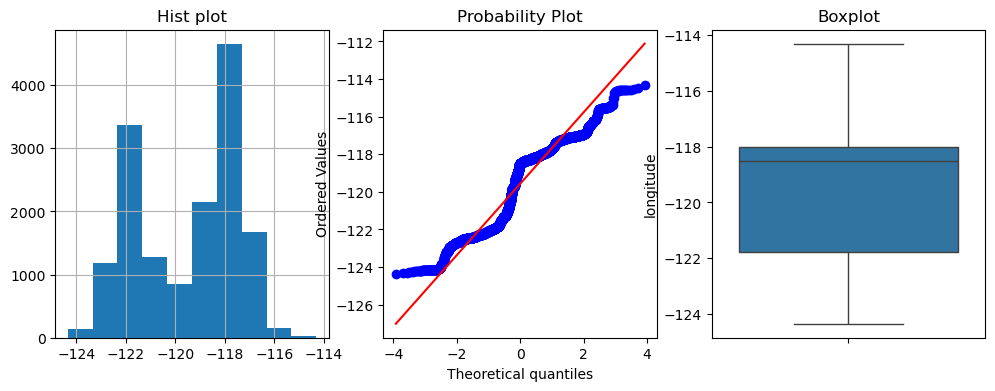

column : latitude


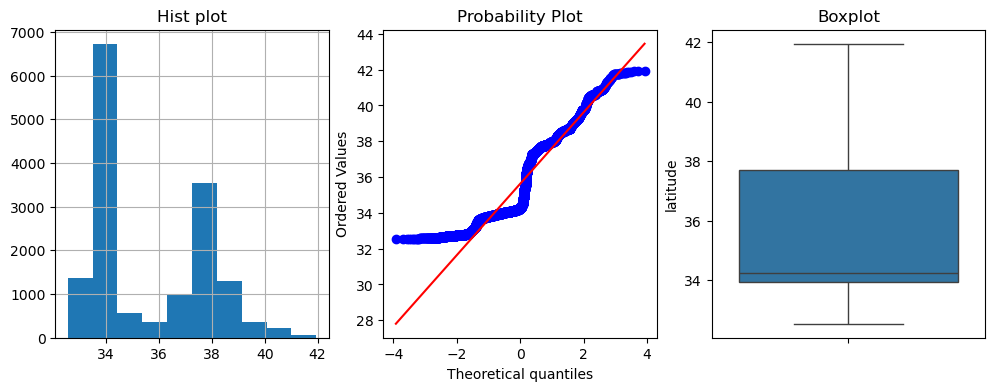

column : housing_median_age


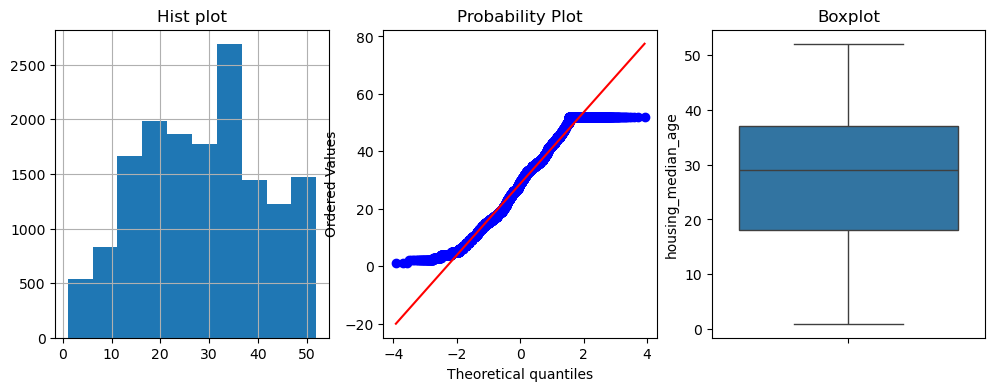

column : total_rooms


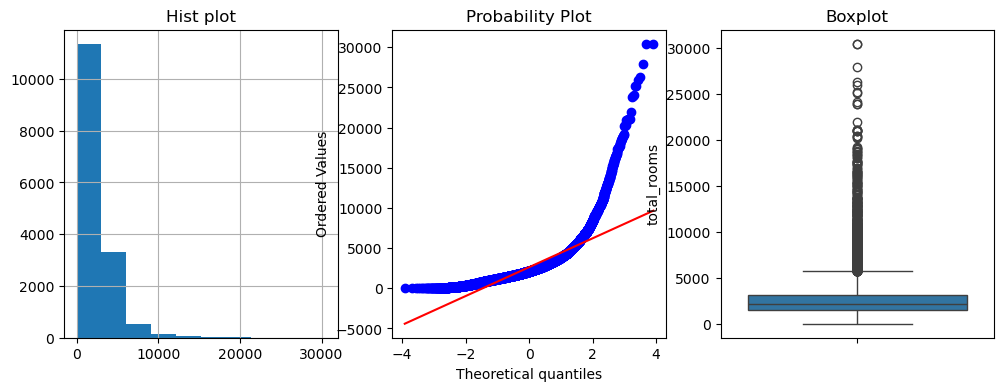

column : total_bedrooms


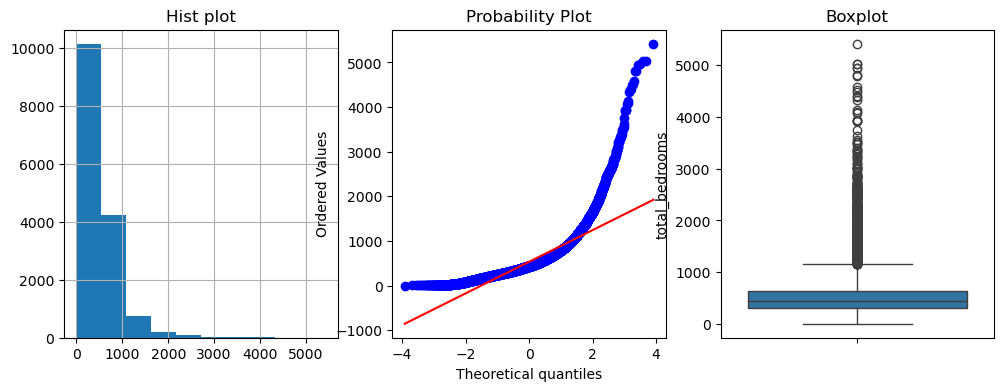

column : population


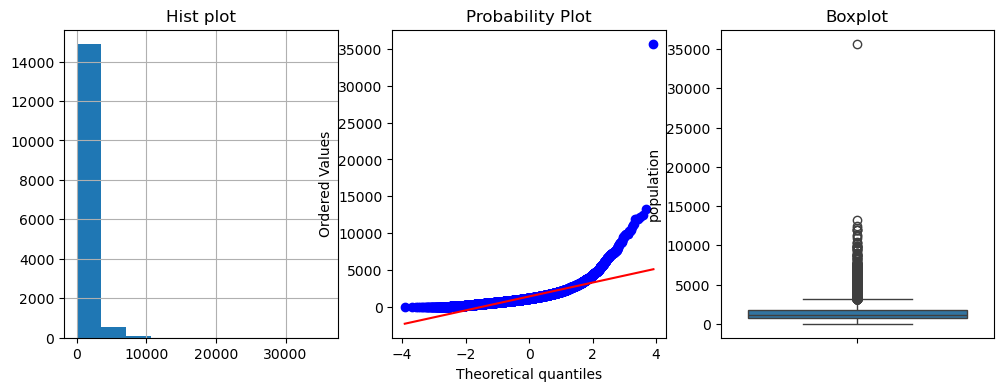

column : households


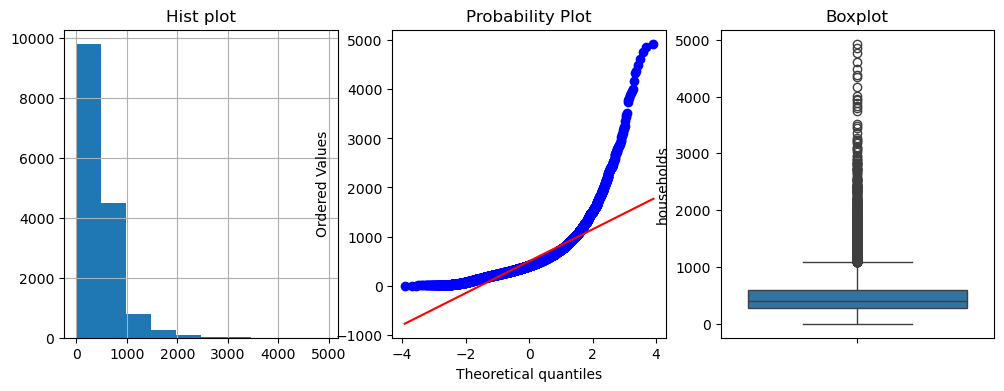

column : median_income


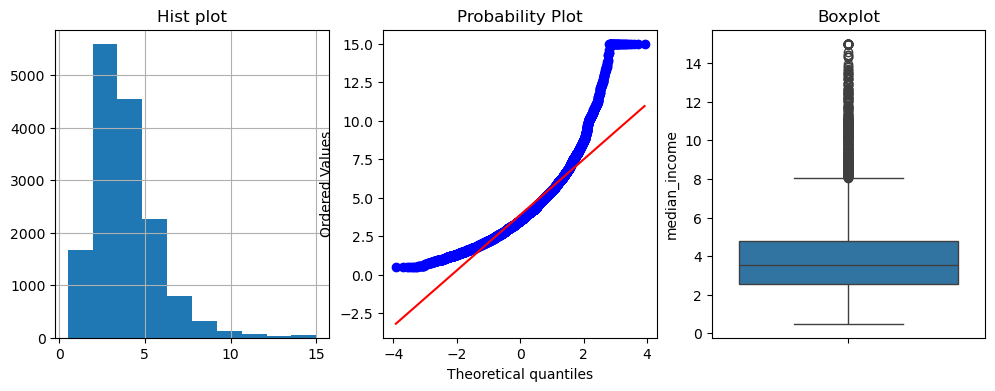

column : median_house_value


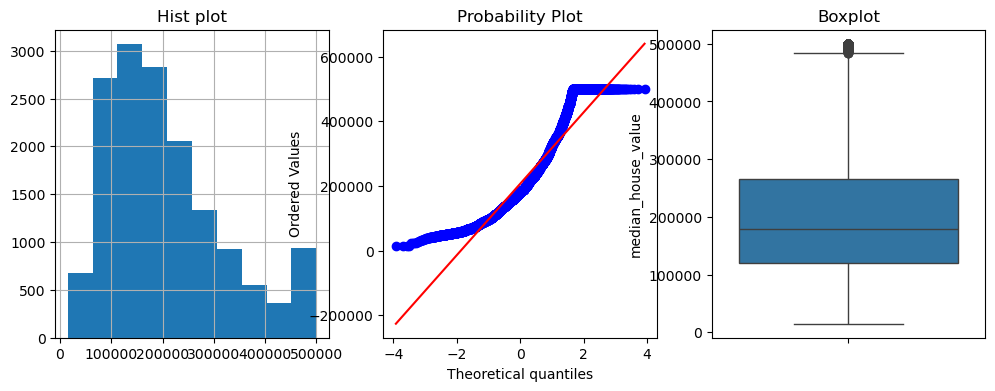

In [58]:
### plotting for the df_train
plot_graphs(df_train)